# Convergence to the steady state

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

## Generate first-order Markov chain, compute spectral gap and left eigenvector

In [ ]:
# Generate the stochastic transition matrix.
def generate_stochastic_matrix(eps, n):
    if not (0 < eps <= 1):
        raise ValueError("eps must be in the range (0, 1].")
    if n < 2:
        raise ValueError("n must be at least 2.")

    P = np.full((n, n), (1 - eps) / (n - 1))

    for i in range(n):
        P[i, (i + 1) % n] = eps

    return P


# Compute the absolute spectral gap of the transition matrix.
def compute_spectral_gap(P):
    eigenvalues = np.linalg.eigvals(P)
    sorted_eigenvalues = np.sort(np.abs(eigenvalues))[::-1]
    spectral_gap = sorted_eigenvalues[0] - sorted_eigenvalues[1]
    return spectral_gap, sorted_eigenvalues


def compute_left_eigenvector(P):
    eigenvalues, eigenvectors = np.linalg.eig(P.T)

    index = np.argmin(np.abs(eigenvalues - 1))
    left_eigenvector = np.real(eigenvectors[:, index])
    left_eigenvector /= np.sum(left_eigenvector)

    return left_eigenvector

## Initial distributions and convergence

In [ ]:
# Generate a random stochastic vector.
def generate_random_stochastic_vector(size):
    return np.random.dirichlet(np.ones(size))


# Iterate an initial state until it converges to the stationary distribution.
def iterative_convergence(P, initial_vector, left_eigenvector,
                          max_iter=100000, tol=1e-4):

    current_vector = initial_vector.copy()
    for iteration in range(1, max_iter + 1):
        current_vector = current_vector @ P

        rel_err = np.max(np.abs(current_vector - left_eigenvector) / left_eigenvector)

        if rel_err < tol:
            return current_vector, iteration
    return current_vector, np.nan

## Simulation

In [ ]:
# Run the convergence experiment for all values of eps.
def run_simulation(eps_values, n, n_initial_states,
                   max_iter=100000, tol=1e-4):

    stat = np.full((len(eps_values), n_initial_states), np.nan)
    list_gap = np.zeros(len(eps_values))

    for i, eps in enumerate(tqdm(eps_values)):
        P = generate_stochastic_matrix(eps, n)
        gap, _ = compute_spectral_gap(P)
        list_gap[i] = gap
        left_eigenvector = compute_left_eigenvector(P)
        for j in range(n_initial_states):
            initial_vector = generate_random_stochastic_vector(n)
            _, iteration = iterative_convergence(
                P,
                initial_vector,
                left_eigenvector,
                max_iter=max_iter,
                tol=tol,
            )
            stat[i, j] = iteration
    return stat, list_gap

## Run parameters

In [ ]:
# Run the simulations

#n = 100
#n_initial_state_vectors = 10^6
#eps_values = np.array([0.60, 0.70, 0.80, 0.90, 0.95])
#tol = 1e-4
#max_iter = 100000
#
#stat, list_gap = run_simulation(
#    eps_values,
#    n,
#    n_initial_state_vectors,
#    max_iter=max_iter,
#    tol=tol,
#)
# save_graph("steady_state_convergence_results", (stat, list_gap))

In [15]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parents[1] / "code"))
from utils import *
(stat, list_gap) = open_graph(r"steady_state_convergence_results")

# Plot convergence times

In [12]:
sns.set_theme(style="ticks", context="paper", palette="colorblind")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 20,
    "axes.titlesize": 25,
    "axes.labelsize": 20,
    "legend.fontsize": 16,
    "legend.title_fontsize": 18,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 1,
    "axes.linewidth": 0.8
})

In [13]:
# Plot distributions of convergence times for different spectral gaps.
def plot_shared_histograms_integer(X, labels, bins=None, alpha=0.7):
    """
    Constructs and plots normalized histograms for each row of a 2D array X.
    All rows share the same x-axis range, and the y-axis shows percentages.
    Assumes the data is integer-valued.
    """
    num_rows = X.shape[0]
    global_min, global_max = 0, X.max()

    if bins is None:
        bins = np.arange(global_min, global_max + 2)

    order = np.argsort(labels)
    X = X[order]
    labels = np.array(labels)[order]

    colors = sns.color_palette("rocket")[1:]

    plt.figure(figsize=(11, 8))

    for i, row in enumerate(X):
        hist, bin_edges = np.histogram(row, bins=bins, density=True)
        hist *= 100 * np.diff(bin_edges)

        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        plt.bar(
            bin_centers,
            hist,
            label=f"{labels[i]:g}",
            color=colors[i],
            alpha=alpha,
            linewidth=0.00,
            width=1
        )

    plt.xlabel("Time to convergence (iterations)", fontsize=30)
    plt.ylabel("Fraction of initial states (%)", fontsize=30)
    plt.tick_params(axis="both", which="major")

    leg = plt.legend(
        title=r"Spectral gap",
        frameon=True,
        bbox_to_anchor=(1.005, 1.01),
    )

    frame = leg.get_frame()
    frame.set_facecolor("white")
    frame.set_edgecolor("black")
    frame.set_linewidth(0.6)
    frame.set_alpha(1.0)

    tick_size = 25

    plt.xlim(global_min, (global_max // tick_size) * tick_size)
    plt.xticks(np.arange(0, global_max + 1, tick_size))

    sns.despine(top=True, right=True)
    plt.tight_layout()

    plt.savefig(
        "histogram_state_convergence.png",
        bbox_inches="tight",
        dpi=300
    )

    plt.show()

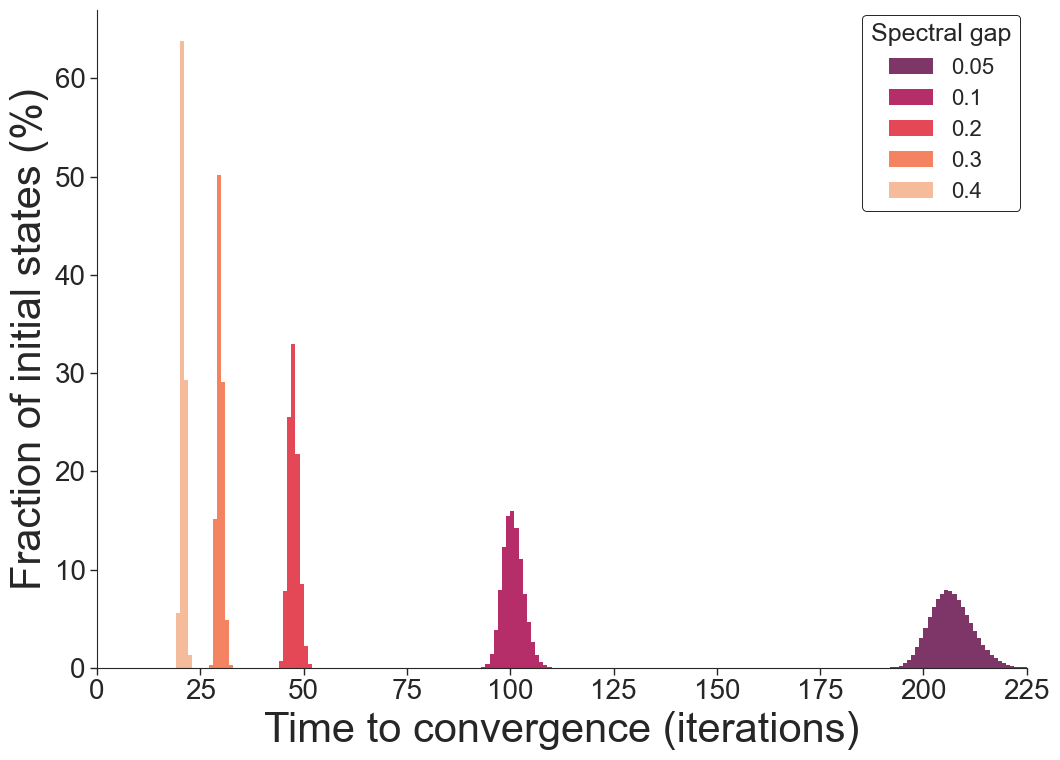

In [14]:
plot_shared_histograms_integer(stat, list_gap, bins=None, alpha=0.9)